In [1]:
import pandas as pd

import matplotlib.pyplot as plt


In [3]:
# Cargar el archivo CSV
file_path = "/home/sergio/experimentos-TID/snapshots_TID_docker_original_javier_2024-12-11_11.30.37.176422.csv"
df = pd.read_csv(file_path, sep="*")



In [4]:
# Crear un array con los nombres de todas las columnas
column_names = df.columns.to_list()

# Mostrar el array para elegir el índice
print("Nombres de las columnas:")
for i, col in enumerate(column_names):
    print(f"{i}: {col}")



Nombres de las columnas:
0: timestamp_pcap
1: timestamp_nfstream
2: timestamp_inference
3: timestamp_detector
4: timestamp_monitoring
5: src_ip
6: dst_ip
7: src_port
8: dst_port
9: protocol
10: pkts
11: bytes


In [20]:
# Inicializar timestamp_column usando el índice del array
selected_index = int(input("Selecciona el índice de la columna que deseas usar como timestamp: "))
timestamp_column = column_names[selected_index]

print(f"Usando '{timestamp_column}' como columna de timestamp.")


Selecciona el índice de la columna que deseas usar como timestamp:  3


Usando 'timestamp_detector' como columna de timestamp.


In [5]:
df


,timestamp,adjusted_timestamp,timestamp_nfstream,timestamp_ai_mon_get_kafka,timestamp_inference,timestamp_ai_mon_put_kafka,timestamp_det_get_kafka,timestamp_detector,timestamp_det_put_kafka,timestamp_ai_mon_get_kafka.1,timestamp_ai_mon_proc_int,src_ip,dst_ip,src_port,dst_port,protocol
0,1.732826e+09,2024-12-10 22:36:27.757697,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,10.0.15.1,207.241.227.221,46378,443,6
1,1.732826e+09,2024-12-10 22:36:27.758697,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,10.0.15.1,207.241.228.11,53180,443,6
2,1.732826e+09,2024-12-10 22:36:27.789697,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,10.0.14.1,207.241.230.21,53610,443,6
3,1.732826e+09,2024-12-10 22:36:28.278697,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,10.0.15.1,207.241.227.221,46378,443,6
4,1.732826e+09,2024-12-10 22:36:28.362697,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,10.0.14.1,207.241.230.21,53610,443,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4932550,1.732827e+09,2024-12-10 22:48:20.325697,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,192.168.4.1,224.0.0.5,0,0,89
4932551,1.732827e+09,2024-12-10 22:48:30.313697,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,192.168.4.2,224.0.0.5,0,0,89
4932552,1.732827e+09,2024-12-10 22:48:30.326697,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,192.168.4.1,224.0.0.5,0,0,89
4932553,1.732827e+09,2024-12-10 22:48:40.320697,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,1.733867e+09,192.168.4.2,224.0.0.5,0,0,89


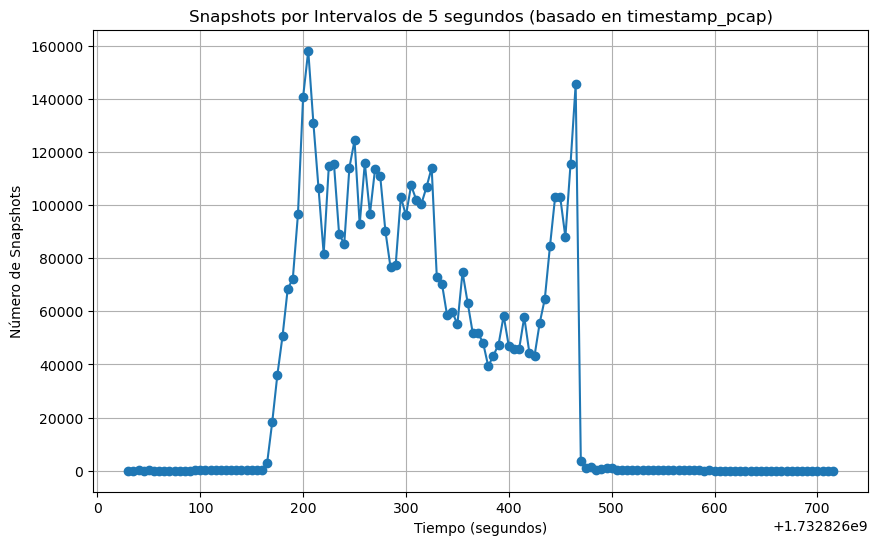

In [15]:


# Asegurarte de que la columna de timestamp esté en formato numérico
df[timestamp_column] = pd.to_numeric(df[timestamp_column], errors='coerce')

# Filtrar valores NaN por si hay timestamps inválidos
df = df.dropna(subset=[timestamp_column])

# Crear una nueva columna para los intervalos de 5 segundos
df['time_bin'] = (df[timestamp_column] // 5 * 5).astype(int)

# Agrupar los snapshots por cada intervalo de tiempo
grouped = df.groupby('time_bin').size().reset_index(name='snapshot_count')

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(grouped['time_bin'], grouped['snapshot_count'], marker='o')
plt.title(f"Snapshots por Intervalos de 5 segundos (basado en {timestamp_column})")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Número de Snapshots")
plt.grid()
plt.show()


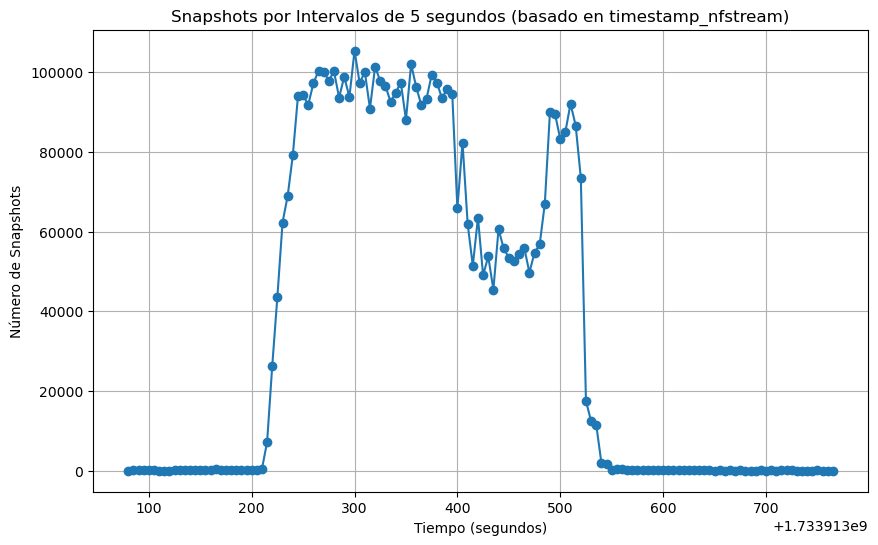

In [17]:


# Asegurarte de que la columna de timestamp esté en formato numérico
df[timestamp_column] = pd.to_numeric(df[timestamp_column], errors='coerce')

# Filtrar valores NaN por si hay timestamps inválidos
df = df.dropna(subset=[timestamp_column])

# Crear una nueva columna para los intervalos de 5 segundos
df['time_bin'] = (df[timestamp_column] // 5 * 5).astype(int)

# Agrupar los snapshots por cada intervalo de tiempo
grouped = df.groupby('time_bin').size().reset_index(name='snapshot_count')

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(grouped['time_bin'], grouped['snapshot_count'], marker='o')
plt.title(f"Snapshots por Intervalos de 5 segundos (basado en {timestamp_column})")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Número de Snapshots")
plt.grid()
plt.show()


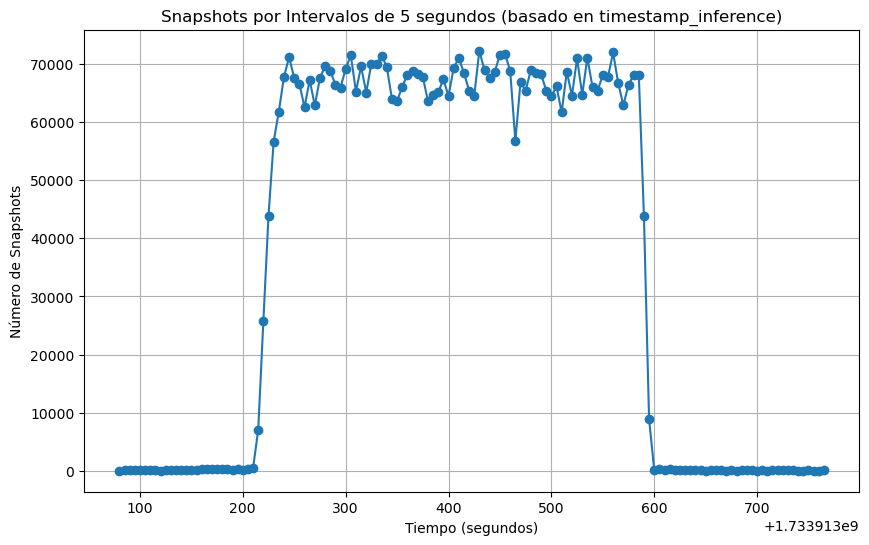

In [19]:


# Asegurarte de que la columna de timestamp esté en formato numérico
df[timestamp_column] = pd.to_numeric(df[timestamp_column], errors='coerce')

# Filtrar valores NaN por si hay timestamps inválidos
df = df.dropna(subset=[timestamp_column])

# Crear una nueva columna para los intervalos de 5 segundos
df['time_bin'] = (df[timestamp_column] // 5 * 5).astype(int)

# Agrupar los snapshots por cada intervalo de tiempo
grouped = df.groupby('time_bin').size().reset_index(name='snapshot_count')

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(grouped['time_bin'], grouped['snapshot_count'], marker='o')
plt.title(f"Snapshots por Intervalos de 5 segundos (basado en {timestamp_column})")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Número de Snapshots")
plt.grid()
plt.show()


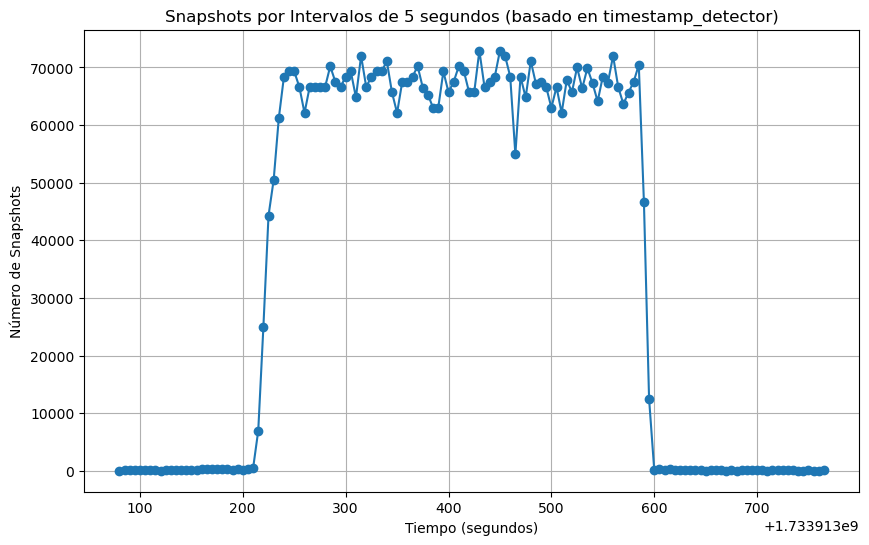

In [21]:


# Asegurarte de que la columna de timestamp esté en formato numérico
df[timestamp_column] = pd.to_numeric(df[timestamp_column], errors='coerce')

# Filtrar valores NaN por si hay timestamps inválidos
df = df.dropna(subset=[timestamp_column])

# Crear una nueva columna para los intervalos de 5 segundos
df['time_bin'] = (df[timestamp_column] // 5 * 5).astype(int)

# Agrupar los snapshots por cada intervalo de tiempo
grouped = df.groupby('time_bin').size().reset_index(name='snapshot_count')

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(grouped['time_bin'], grouped['snapshot_count'], marker='o')
plt.title(f"Snapshots por Intervalos de 5 segundos (basado en {timestamp_column})")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Número de Snapshots")
plt.grid()
plt.show()


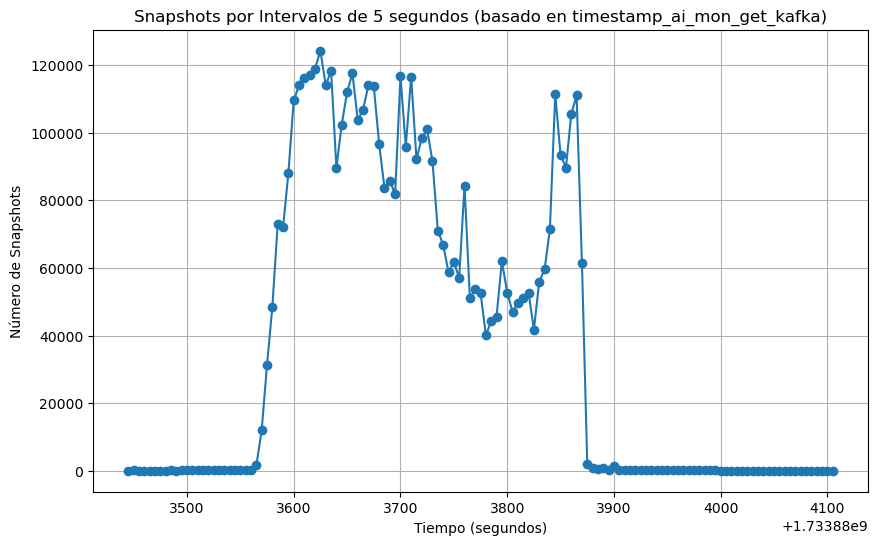

In [6]:


# Asegurarte de que la columna de timestamp esté en formato numérico
df[timestamp_column] = pd.to_numeric(df[timestamp_column], errors='coerce')

# Filtrar valores NaN por si hay timestamps inválidos
df = df.dropna(subset=[timestamp_column])

# Crear una nueva columna para los intervalos de 5 segundos
df['time_bin'] = (df[timestamp_column] // 5 * 5).astype(int)

# Agrupar los snapshots por cada intervalo de tiempo
grouped = df.groupby('time_bin').size().reset_index(name='snapshot_count')

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(grouped['time_bin'], grouped['snapshot_count'], marker='o')
plt.title(f"Snapshots por Intervalos de 5 segundos (basado en {timestamp_column})")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Número de Snapshots")
plt.grid()
plt.show()


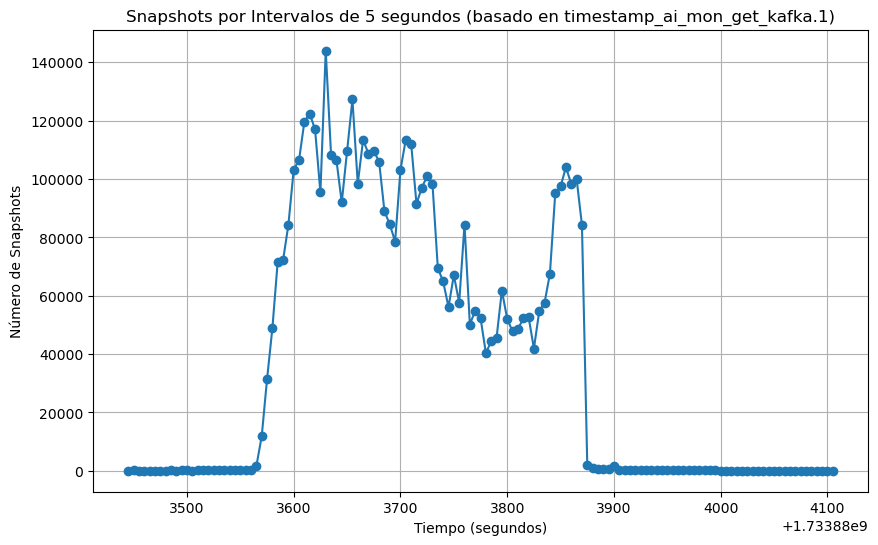

In [10]:


# Asegurarte de que la columna de timestamp esté en formato numérico
df[timestamp_column] = pd.to_numeric(df[timestamp_column], errors='coerce')

# Filtrar valores NaN por si hay timestamps inválidos
df = df.dropna(subset=[timestamp_column])

# Crear una nueva columna para los intervalos de 5 segundos
df['time_bin'] = (df[timestamp_column] // 5 * 5).astype(int)

# Agrupar los snapshots por cada intervalo de tiempo
grouped = df.groupby('time_bin').size().reset_index(name='snapshot_count')

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(grouped['time_bin'], grouped['snapshot_count'], marker='o')
plt.title(f"Snapshots por Intervalos de 5 segundos (basado en {timestamp_column})")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Número de Snapshots")
plt.grid()
plt.show()


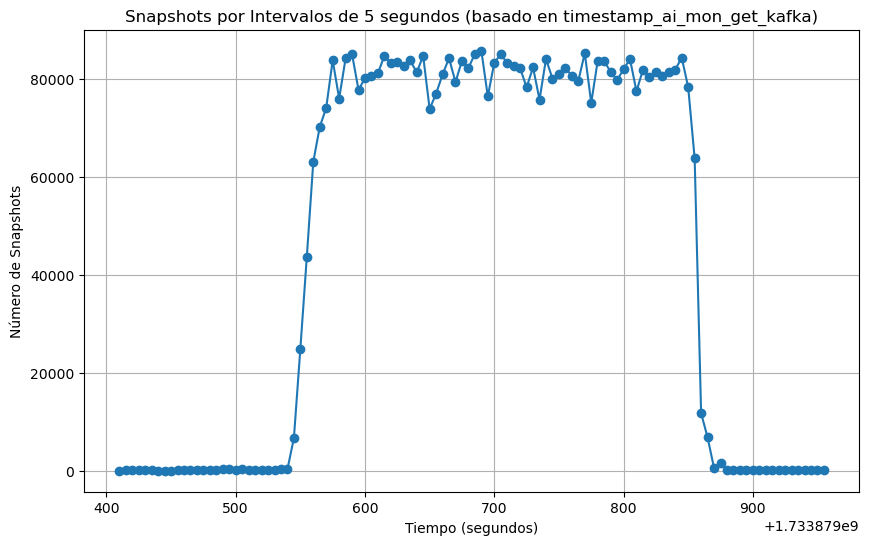

In [30]:


# Asegurarte de que la columna de timestamp esté en formato numérico
df[timestamp_column] = pd.to_numeric(df[timestamp_column], errors='coerce')

# Filtrar valores NaN por si hay timestamps inválidos
df = df.dropna(subset=[timestamp_column])

# Crear una nueva columna para los intervalos de 5 segundos
df['time_bin'] = (df[timestamp_column] // 5 * 5).astype(int)

# Agrupar los snapshots por cada intervalo de tiempo
grouped = df.groupby('time_bin').size().reset_index(name='snapshot_count')

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(grouped['time_bin'], grouped['snapshot_count'], marker='o')
plt.title(f"Snapshots por Intervalos de 5 segundos (basado en {timestamp_column})")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Número de Snapshots")
plt.grid()
plt.show()


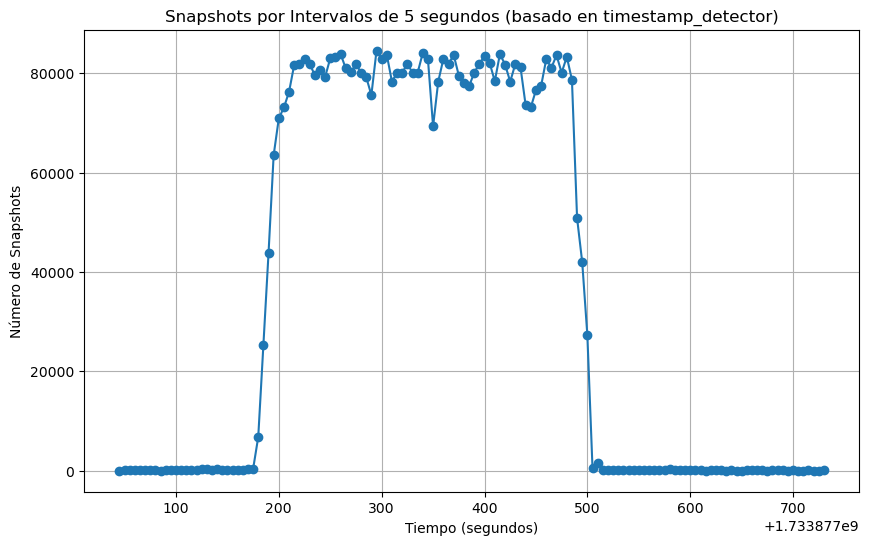

In [25]:


# Asegurarte de que la columna de timestamp esté en formato numérico
df[timestamp_column] = pd.to_numeric(df[timestamp_column], errors='coerce')

# Filtrar valores NaN por si hay timestamps inválidos
df = df.dropna(subset=[timestamp_column])

# Crear una nueva columna para los intervalos de 5 segundos
df['time_bin'] = (df[timestamp_column] // 5 * 5).astype(int)

# Agrupar los snapshots por cada intervalo de tiempo
grouped = df.groupby('time_bin').size().reset_index(name='snapshot_count')

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(grouped['time_bin'], grouped['snapshot_count'], marker='o')
plt.title(f"Snapshots por Intervalos de 5 segundos (basado en {timestamp_column})")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Número de Snapshots")
plt.grid()
plt.show()
